### Name : Malak Darwish Ammar ###
### Student NUM : 2320222003 ###
### Assignment 1 ###


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#### Loading: Use pandas to read both train.csv and test.csv ###

In [11]:
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

#### Dataset Inspection: Print the dimensions and display the first five rows ####

In [12]:
print(f"Training Set Shape: {train_df.shape}")
print(f"Testing Set Shape: {test_df.shape}")

print("\nFirst 5 rows of the Training Set:")
display(train_df.head())

Training Set Shape: (1460, 81)
Testing Set Shape: (1459, 80)

First 5 rows of the Training Set:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


#### Memory Management Function ####

In [17]:
def optimize_memory(df):
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = df[col].astype('category')
        elif df[col].dtype == 'float64':
            df[col] = df[col].astype('float32')
        elif df[col].dtype == 'int64':
            df[col] = pd.to_numeric(df[col], downcast='integer')
    return df

# Apply optimization
train_df = optimize_memory(train_df)
test_df = optimize_memory(test_df)

print("\nMemory optimization completed.")
train_df.info(memory_usage='deep')


Memory optimization completed.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Id             1460 non-null   int16   
 1   MSSubClass     1460 non-null   int16   
 2   MSZoning       1460 non-null   category
 3   LotFrontage    1201 non-null   float32 
 4   LotArea        1460 non-null   int32   
 5   Street         1460 non-null   category
 6   Alley          91 non-null     category
 7   LotShape       1460 non-null   category
 8   LandContour    1460 non-null   category
 9   Utilities      1460 non-null   category
 10  LotConfig      1460 non-null   category
 11  LandSlope      1460 non-null   category
 12  Neighborhood   1460 non-null   category
 13  Condition1     1460 non-null   category
 14  Condition2     1460 non-null   category
 15  BldgType       1460 non-null   category
 16  HouseStyle     1460 non-null   category
 17  O

#### Handling Missing Values ####

In [21]:
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu']
for col in none_cols:
    if col in train_df.columns:
        # Ensure it's category type and fill NaN with 'None'
        if train_df[col].dtype.name != 'category':
            train_df[col] = train_df[col].astype('category')
        train_df[col] = train_df[col].cat.add_categories(['None']).fillna('None')

# 2. Outlier Removal
# Removing houses with extreme ground living area but low sale price
train_df = train_df.drop(train_df[(train_df['GrLivArea'] > 4000) & (train_df['SalePrice'] < 300000)].index)

# 3. Target Transformation
# Normalizing the right-skewed SalePrice using log transformation
train_df['SalePrice'] = np.log1p(train_df['SalePrice'])

print("Data cleaning and log transformation applied.")

Data cleaning and log transformation applied.


#### Exploratory Data Analysis (EDA) ####

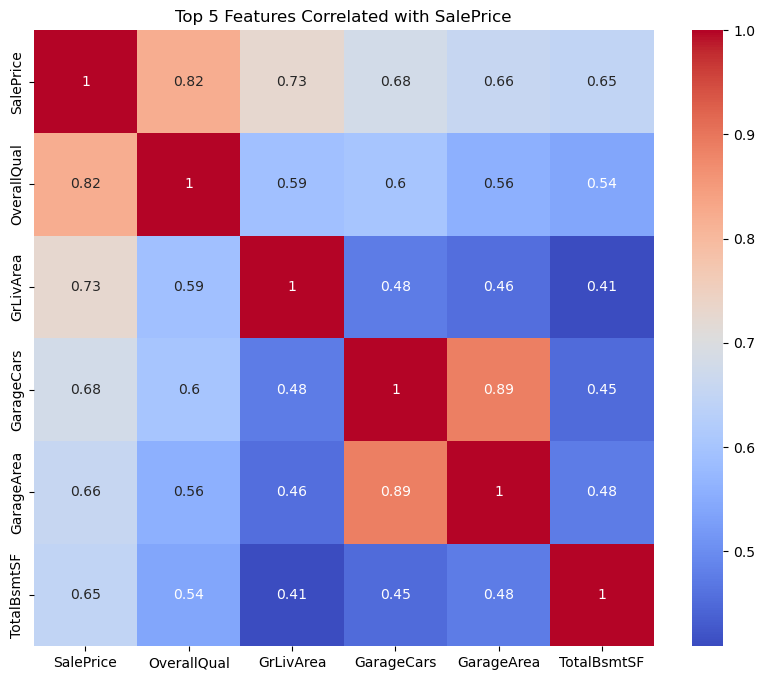

In [26]:
#  Correlation Matrix & Heatmap
numeric_df = train_df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

top_features = corr_matrix['SalePrice'].sort_values(ascending=False).head(6).index

plt.figure(figsize=(10, 8))
sns.heatmap(train_df[top_features].corr(), annot=True, cmap='coolwarm')
plt.title('Top 5 Features Correlated with SalePrice')
plt.show()


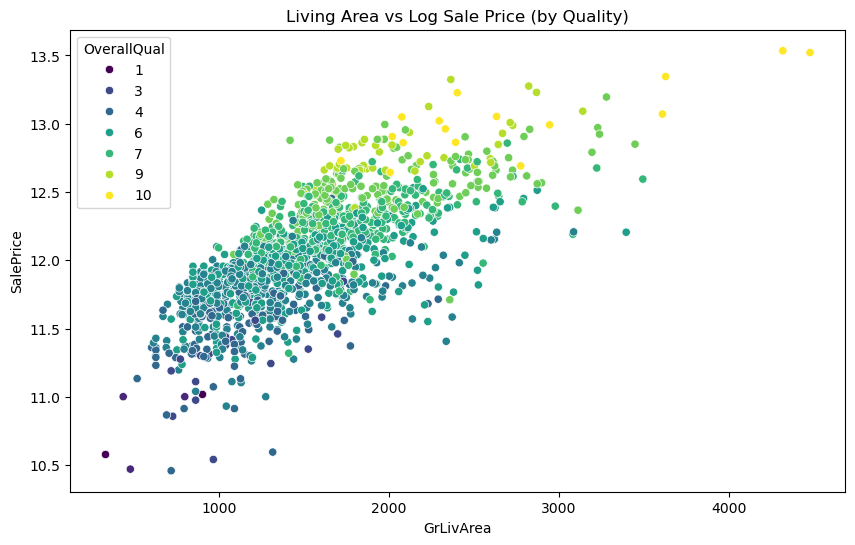

In [25]:
#  Visual Exploration (GrLivArea vs SalePrice)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=train_df, x='GrLivArea', y='SalePrice', hue='OverallQual', palette='viridis')
plt.title('Living Area vs Log Sale Price (by Quality)')
plt.show()

#### Feature Engineering & Encoding ####

In [31]:
# Feature Transformation: Create Total Square Footage
# Create TotalSF feature for both training and testing sets
# We fill missing basement values with 0 to ensure the sum is calculated correctly
train_df['TotalSF'] = train_df['TotalBsmtSF'].fillna(0) + train_df['1stFlrSF'] + train_df['2ndFlrSF']
test_df['TotalSF'] = test_df['TotalBsmtSF'].fillna(0) + test_df['1stFlrSF'] + test_df['2ndFlrSF']

print("New feature 'TotalSF' added to both datasets.")

New feature 'TotalSF' added to both datasets.


In [32]:
# A. Label Encoding for Ordinal Features (Preserving Rank)
# Define the quality mapping based on the dataset description
qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}
ordinal_cols = ['ExterQual', 'KitchenQual', 'BsmtQual', 'HeatingQC']

for col in ordinal_cols:
    if col in train_df.columns:
        # Convert to string to handle category dtypes and apply mapping
        train_df[col] = train_df[col].astype(str).map(qual_map).fillna(0)
    if col in test_df.columns:
        test_df[col] = test_df[col].astype(str).map(qual_map).fillna(0)

# B. One-Hot Encoding for Nominal Features
# We encode 'Neighborhood' and 'BldgType' as per requirements
train_df = pd.get_dummies(train_df, columns=['Neighborhood', 'BldgType'], drop_first=True)
test_df = pd.get_dummies(test_df, columns=['Neighborhood', 'BldgType'], drop_first=True)

print("Categorical variables encoded successfully.")

Categorical variables encoded successfully.


#### Pipeline Construction ####

In [33]:
def final_preprocessing_pipeline(df):
    """
    Reusable function to apply data cleaning and feature engineering consistently.
    """
    # 1. Fill numeric missing values with median to handle potential outliers
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
    
    # 2. Add TotalSF if not already created
    if 'TotalSF' not in df.columns:
        df['TotalSF'] = df['TotalBsmtSF'].fillna(0) + df['1stFlrSF'] + df['2ndFlrSF']
        
    return df

# Applying the final pipeline check
train_df = final_preprocessing_pipeline(train_df)
test_df = final_preprocessing_pipeline(test_df)

print(f"Final training set shape: {train_df.shape}")

Final training set shape: (1458, 108)
